(risk_aversion_or_mistaken_beliefs)=
```{raw} html
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# Risk Aversion or Mistaken Beliefs?

## Overview

This lecture explores how *risk aversion* and *mistaken beliefs* are confounded in asset pricing data.

In a rational expectations equilibrium containing a risk-averse representative investor, higher mean returns compensate for higher risks.

But in a non-rational expectations model in which a representative investor holds beliefs that differ from "the econometrician's", observed average returns depend on *both* risk aversion *and* misunderstood return distributions.

```{note}
Whether  beliefs are 'correct' or 'wrong' is itself subjective -- it depends on an observer's point of view.
```

Wrong beliefs contribute what look like "stochastic discount factor shocks" when viewed from the perspective of an econometrician who trusts his model.

Such divergent beliefs can potentially explain what look like countercyclical risk price from the perpective of someone who trusts the
econometrician's model. 

A key building block of this model will be an econometrician's model that takes the form of a linear state-space model driven by Gaussian disturbances.  

This model will play two key roles:

* it forms the perspective from which 'mistaken' beliefs and their consequences are viewed
* it forms the 'baseline' model of a dubious representative agent who distrusts it and wants to value assets payoffs by using alternative models that
seem to fit the historical data about as well as does the 'baseline' model.

```{note}
When we discuss the setup with a twisted entry ball below, the econometrician's model will be one of *two* baseline models that the distrustful agent is concerned about. 
```

We'll formalize  different beliefs in terms of divergent probability distributions. 

It is convenient to characterize those differences in terms of a likelihood ratio process, the object studied in this quantecon lecture
{doc}`likelihood_ratio_process`.

Thus, we'll organize this lecture around a single mathematical device, namely, a **likelihood ratio**, a non-negative random variable with unit mean that twists one probability distribution into another.

Likelihood ratios, equivalently multiplicative martingale increments, appear in at least four distinct roles in modern asset pricing:

| Probability   | Likelihood ratio                  | Describes             |
|:--------------|:----------------------------------|:----------------------|
| Econometric   | $1$ (no twist)                    | macro risk factors    |
| Risk neutral  | $m_{t+1}^\lambda$                 | prices of risks       |
| Mistaken      | $m_{t+1}^w$                       | experts' forecasts    |
| Doubtful      | $m_{t+1} \in \mathcal{M}$         | misspecification fears|

Each of the key  likelihood ratios in this lecture  takes the log-normal form
$m_{t+1}^b = \exp(-b_t^\top \varepsilon_{t+1} - \frac{1}{2} b_t^\top b_t)$
with $b_t = 0$, $\lambda_t$, $w_t$, or a worst-case distortion.

The lecture draws primarily on three lines of work:

1. {cite:t}`Lucas1978` and {cite:t}`hansen1983stochastic`: a representative investor's risk
   aversion generates a likelihood ratio that prices risks.
2. {cite:t}`piazzesi2015trend`: survey data on professional forecasters
   decompose the likelihood ratio into a smaller risk price and a belief distortion.
3. {cite:t}`hansen2020twisted` and {cite:t}`szoke2022estimating`: robust control theory
   constructs twisted probability models from tilted discounted entropy balls to
   price model uncertainty, generating state-dependent uncertainty prices that
   explain puzzling term-structure movements.

We start with some standard imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import solve_discrete_lyapunov
from numpy.linalg import eigvals, norm
from scipy.stats import norm as normal_dist

## Likelihood ratios and twisted densities


Let $\varepsilon$ denote a vector of risks to be taken and priced. 

Under the econometrician's probability model, $\varepsilon$ has a standard multivariate normal density:

```{math}
:label: eq_baseline

\phi(\varepsilon) \propto \exp \left(-\frac{1}{2} \varepsilon^\top\varepsilon\right), \qquad \varepsilon \sim \mathcal{N}(0, I)
```

To twist this baseline density into another one, we multiply it by a non-negative random variable with unit mean called a **likelihood ratio**:

```{math}
:label: eq_lr

m(\varepsilon) = \exp \left(-\lambda^\top\varepsilon - \frac{1}{2} \lambda^\top\lambda\right) \geq 0
```

The quadratic term $-\frac{1}{2}\lambda^\top\lambda$ in the exponent is precisely what guarantees $E  m(\varepsilon) = 1$ when the mathematical expectation $E$ is taken with respect to the econometrician's model.

Multiplying the baseline density by this likelihood ratio produces the **twisted density**:

```{math}
:label: eq_twisted

\hat\phi(\varepsilon) = m(\varepsilon) \phi(\varepsilon) \propto \exp \left(-\frac{1}{2}(\varepsilon + \lambda)^\top(\varepsilon + \lambda)\right)
```

Completing the square in the exponent reveals that this is a $\mathcal{N}(-\lambda, I)$ density.

The likelihood ratio has shifted the mean of $\varepsilon$ from $0$ to $-\lambda$ while preserving the covariance.

We will see this idea repeatedly in different contexts.

````{exercise}
:label: lr_exercise_1

Verify that:

1. $E m(\varepsilon) = 1$ by computing $\int m(\varepsilon) \phi(\varepsilon) d\varepsilon$ using the moment-generating function of a standard normal.
2. The twisted density $\hat\phi(\varepsilon) = m(\varepsilon) \phi(\varepsilon)$ is indeed $\mathcal{N}(-\lambda, I)$ by combining exponents:

$$
m(\varepsilon) \phi(\varepsilon) \propto \exp \left(-\lambda^\top\varepsilon - \tfrac{1}{2}\lambda^\top\lambda\right) \exp \left(-\tfrac{1}{2}\varepsilon^\top\varepsilon\right) = \exp \left(-\tfrac{1}{2}\bigl[\varepsilon^\top\varepsilon + 2\lambda^\top\varepsilon + \lambda^\top\lambda\bigr]\right)
$$

and complete the square to obtain $-\frac{1}{2}(\varepsilon + \lambda)^\top(\varepsilon + \lambda)$.

````

````{solution} lr_exercise_1
:class: dropdown

For part 1, write $E m(\varepsilon) = \int \exp(-\lambda^\top\varepsilon - \tfrac{1}{2}\lambda^\top\lambda) \phi(\varepsilon) d\varepsilon = \exp(-\tfrac{1}{2}\lambda^\top\lambda) E[\exp(-\lambda^\top\varepsilon)]$.

The moment-generating function of $\varepsilon \sim \mathcal{N}(0,I)$ (or expectation of the log-normal random variable) gives $E[\exp(-\lambda^\top\varepsilon)] = \exp(\tfrac{1}{2}\lambda^\top\lambda)$.

So $E m(\varepsilon) = \exp(-\tfrac{1}{2}\lambda^\top\lambda)\exp(\tfrac{1}{2}\lambda^\top\lambda) = 1$. 

For part 2, combine the exponents:

$$
m(\varepsilon) \phi(\varepsilon) \propto \exp \left(-\tfrac{1}{2}\varepsilon^\top\varepsilon - \lambda^\top\varepsilon - \tfrac{1}{2}\lambda^\top\lambda\right)
$$

Recognise the argument as $-\tfrac{1}{2}(\varepsilon^\top\varepsilon + 2\lambda^\top\varepsilon + \lambda^\top\lambda) = -\tfrac{1}{2}(\varepsilon + \lambda)^\top(\varepsilon + \lambda)$.

This is the kernel of a $\mathcal{N}(-\lambda, I)$ density. 

````

### Relative entropy

How far apart are the baseline and twisted densities?

The **relative entropy** (Kullback-Leibler divergence) answers this question with a single number:

```{math}
:label: eq_entropy

E\bigl[m(\varepsilon)\log m(\varepsilon)\bigr] = \frac{1}{2} \lambda^\top\lambda
```

Because it equals half the squared length of $\lambda$, larger distortion vectors correspond to greater statistical distance between the two models.

The vector $\lambda$ is the key object.

Depending on context it represents *risk prices*, *belief distortions*, or *worst-case mean perturbations* under model uncertainty.

For illustration, consider the scalar case $\varepsilon \in \mathbb{R}$ with $\lambda = 1.5$.

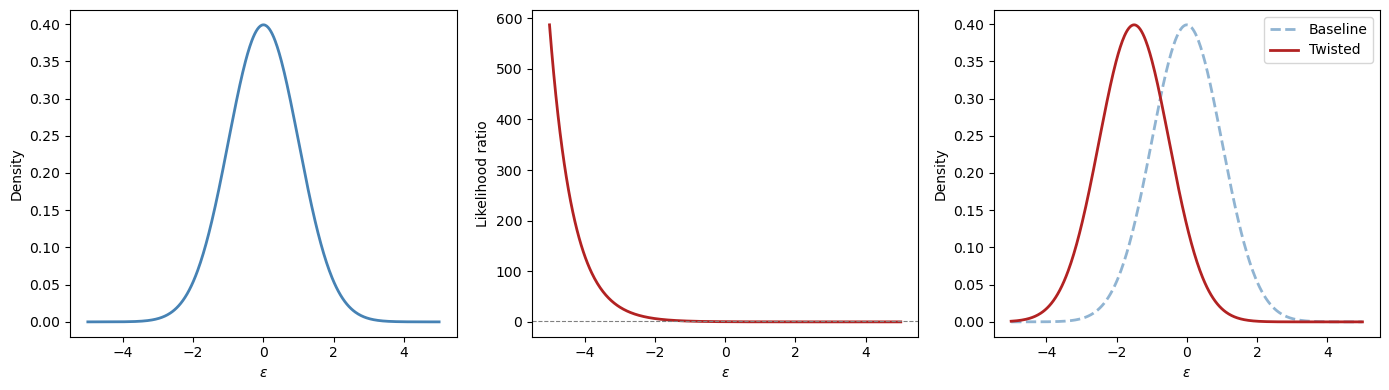

In [2]:
ε = np.linspace(-5, 5, 500)
λ_val = 1.5

ϕ_base  = normal_dist.pdf(ε, 0, 1)
m_lr    = np.exp(-λ_val * ε - 0.5 * λ_val**2)
ϕ_twist = m_lr * ϕ_base

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ε, ϕ_base, 'steelblue', lw=2)
axes[0].set_xlabel(r"$\varepsilon$")

axes[1].plot(ε, m_lr, 'firebrick', lw=2)
axes[1].axhline(1, color='grey', lw=0.8, ls='--')
axes[1].set_xlabel(r"$\varepsilon$")

axes[2].plot(ε, ϕ_base, 'steelblue', lw=2,
             ls='--', alpha=0.6, label='Baseline')
axes[2].plot(ε, ϕ_twist, 'firebrick', lw=2,
             label='Twisted')
axes[2].set_xlabel(r"$\varepsilon$")
axes[2].legend()

axes[0].set_ylabel("Density")
axes[1].set_ylabel("Likelihood ratio")
axes[2].set_ylabel("Density")
plt.tight_layout()
plt.show()

The left panel shows the baseline $\mathcal{N}(0,1)$ density.

The middle panel shows the likelihood ratio $m(\varepsilon)$, which up-weights negative $\varepsilon$ values and down-weights positive ones when $\lambda > 0$.

The right panel shows the resulting twisted density $\hat\phi(\varepsilon) = \mathcal{N}(-\lambda, 1)$.


## The econometrician's state-space model

The econometrician works with a linear Gaussian state-space system at a *monthly* frequency.

The state $x_t$, an augmented $n \times 1$ vector, evolves according to:

```{math}
:label: eq_state

x_{t+1} = A x_t + C \varepsilon_{t+1}
```

The econometrician observes $y_{t+1}$, which is a noisy linear function of the state and the same shocks:

```{math}
:label: eq_obs

y_{t+1} = D x_t + G \varepsilon_{t+1}
```

The $k \times 1$ shock vector driving both equations is i.i.d. standard normal:

```{math}
:label: eq_shocks

\varepsilon_{t+1} \sim \mathcal{N}(0, I)
```

To accommodate constant terms easily, we assume that the first entry in the state vector is a constant $1$ so that

$$
x_t = \begin{bmatrix} 1 \\ \check{x}_t \end{bmatrix}, \qquad
A = \begin{bmatrix} 1 & 0 \\ 0 & \check{A} \end{bmatrix}, \qquad
C = \begin{bmatrix} 0 \\ \check{C} \end{bmatrix}
$$

where $\check{A}$ is a stable matrix, $\check{C}$ is square and invertible, and the first component of $x_0$ is $1$.

With this convention, the number of shocks equals the dimension of the stochastic block: $k = n - 1$.

Whenever we back out distortion coefficient matrices from alternative transition matrices, we invert only the lower block $\check{C}$ and compare the lower rows of the augmented transition matrices, not the full augmented matrix $C$.

Whenever we refer to stability below, we mean stability of the stochastic block $\check{A}$ (or its distorted counterpart).

The observation $y_{t+1}$ represents consumption growth, $c_{t+1} - c_t = D x_t + G \varepsilon_{t+1}$.

Separately, the risk-free one-period interest rate is a linear function of the augmented state:

$$
r_t = \bar{r}^\top x_t
$$

```{figure} /_static/lecture_specific/risk_aversion_or_mistaken_beliefs/fig2_tom.png
The econometrician's model: estimated state dynamics.
```


## Asset pricing with likelihood ratios

### Risk-neutral rational expectations pricing

The simplest benchmark is a risk-neutral representative investor with rational expectations, for whom the stock price $p_t$ (the ex-dividend market value of a claim to the stream $\{d_{t+j}\}_{j=1}^\infty$) is simply the discounted expected payoff:

$$
p_t = \exp(-r_t) E_t(p_{t+1} + d_{t+1})
$$

The same logic applies maturity by maturity to the term structure: a zero-coupon risk-free claim to one dollar at time $t+n$ is priced by iterating the one-period discounting:

```{math}
:label: eq_rn_recursion

p_t(1) = \exp(-r_t), \qquad p_t(n+1) = \exp(-r_t) E_t p_{t+1}(n), \qquad p_t(n) = \exp(\bar{A}_n^{RN} + B_n^{RN} x_t)
```

The last equality states that bond prices take an **exponential-affine** form in the state.

This is a consequence of the linear Gaussian structure and can be verified by substituting the guess into the recursion and matching coefficients (see {ref}`Exercise 3 <arp_ex3>` in {doc}`Affine Models of Asset Prices <affine_risk_prices>`).

These formulas work "pretty well" for conditional means but less well for conditional variances, i.e. the Shiller *volatility puzzles*.

### Modern asset pricing: adding risk aversion

It would be convenient if versions of the same pricing formulas worked even when investors are risk averse or hold distorted beliefs.

The likelihood ratio makes this possible.

We now promote the static vector $\lambda$ from {eq}`eq_lr` to a *state-dependent* risk price vector.

With a slight abuse of notation, we now let $\lambda$ denote a $k \times n$ **matrix** of risk price coefficients, so that $\lambda_t = \lambda x_t$ is a $k \times 1$ vector at each date $t$.

In the code below, this matrix is the parameter `Λ`.

The likelihood ratio increment is

```{math}
:label: eq_sdf_lr

m_{t+1}^\lambda = \exp \left(-\lambda_t^\top \varepsilon_{t+1} - \frac{1}{2} \lambda_t^\top\lambda_t\right), \qquad \lambda_t = \lambda x_t
```

with $E_t m_{t+1}^\lambda = 1$ and $m_{t+1}^\lambda \geq 0$.

The likelihood ratio $m_{t+1}^\lambda$ distorts the conditional distribution of $\varepsilon_{t+1}$ from $\mathcal{N}(0,I)$ to $\mathcal{N}(-\lambda x_t, I)$.

Covariances of returns with $m_{t+1}^\lambda$ affect mean returns.

This is the channel through which risk aversion prices risks.

With this device, *modern asset pricing* replaces the ordinary conditional expectation with one that is tilted by the likelihood ratio.

For stocks, the Lucas-Hansen pricing equation discounts the next-period payoff under the distorted measure:

```{math}
:label: eq_stock_lr

p_t = \exp(-r_t) E_t\bigl(m_{t+1}^\lambda (p_{t+1} + d_{t+1})\bigr)
```

For the term structure, Dai-Singleton-Backus-Zin pricing applies the same distortion recursively across maturities:

```{math}
:label: eq_ts_lr

p_t(1) = \exp(-r_t), \qquad p_t(n+1) = \exp(-r_t) E_t\bigl(m_{t+1}^\lambda p_{t+1}(n)\bigr), \qquad p_t(n) = \exp(\bar{A}_n + B_n x_t)
```

The coefficients $\bar{A}_n$, $B_n$ here differ from the risk-neutral coefficients $\bar{A}_n^{RN}$, $B_n^{RN}$ in {eq}`eq_rn_recursion` because the likelihood ratio modifies the recursion.

### Risk-neutral dynamics

The risk-neutral representation implies **twisted dynamics**.

Under the twisted measure, define $\tilde\varepsilon_{t+1} := \varepsilon_{t+1} + \lambda_t = \varepsilon_{t+1} + \lambda  x_t$.

Since $\varepsilon_{t+1} \sim \mathcal{N}(0, I)$ under the econometrician's measure, $\tilde\varepsilon_{t+1}$ has mean $\lambda x_t$ and is *not* standard normal under that measure.

However, the likelihood ratio $m_{t+1}^\lambda \propto \exp\bigl(-(\lambda x_t)^\top \varepsilon_{t+1} - \tfrac{1}{2}\|\lambda x_t\|^2\bigr)$ tilts the probability measure in exactly the right way to absorb this shift.

By the standard exponential tilting result for Gaussian models, $\tilde\varepsilon_{t+1} \sim \mathcal{N}(0, I)$ under the risk-neutral measure.

Substituting $\varepsilon_{t+1} = \tilde\varepsilon_{t+1} - \lambda  x_t$ into {eq}`eq_state` gives:

```{math}
:label: eq_rn_dynamics

x_{t+1} = (A - C\lambda) x_t + C \tilde\varepsilon_{t+1}, \qquad \tilde\varepsilon_{t+1} \sim \mathcal{N}(0,I)
```

The dependence of $\lambda_t = \lambda x_t$ on the state modifies the dynamics relative to the econometrician's model.

### Expectation under a twisted distribution

A useful notational shorthand captures the connection between the two measures: the expected value of $y_{t+1}$ under the twisted distribution can be computed as a likelihood-ratio-weighted average under the original distribution:

$$
\tilde{E}_t y_{t+1} = E_t m_{t+1} y_{t+1}
$$

With this notation, the term structure recursion under risk-neutral dynamics takes a particularly clean form:

$$
p_t(1) = \exp(-r_t), \qquad p_t(n+1) = \exp(-r_t) \tilde{E}_t p_{t+1}(n), \qquad p_t(n) = \exp(\tilde{\bar{A}}_n + \tilde{B}_n x_t)
$$

These are the same formulas as rational-expectations asset pricing, but expectations are taken with respect to a probability measure *twisted by risk aversion*.

The derivation of the recursive bond price coefficients is the same as in {ref}`Exercise 3 <arp_ex3>` of {doc}`Affine Models of Asset Prices <affine_risk_prices>`, applied here under the risk-neutral dynamics {eq}`eq_rn_dynamics`.

Now let's implement the state-space model and its asset pricing implications.

In [3]:
class LikelihoodRatioModel:
    """
    Gaussian state-space model with an augmented constant state.

    x_{t+1} = A x_t + C ε_{t+1},  ε ~ N(0,I),  x_t[0] = 1
    y_{t+1} = D x_t + G ε_{t+1}
    r_t = r_bar'x_t,  λ_t = Λ x_t
    """

    def __init__(self, A, C, D, G, r_bar, Λ):
        self.A = np.atleast_2d(A).astype(float)
        self.C = np.atleast_2d(C).astype(float)
        self.D = np.atleast_2d(D).astype(float)
        self.G = np.atleast_2d(G).astype(float)
        self.r_bar = np.asarray(r_bar, dtype=float)
        self.Λ = np.atleast_2d(Λ).astype(float)
        self.n = self.A.shape[0]
        self.k = self.C.shape[1]
        # risk-neutral dynamics
        self.A_Q = self.A - self.C @ self.Λ
        self.A_core = self.A[1:, 1:]
        self.A_Q_core = self.A_Q[1:, 1:]

    def short_rate(self, x):
        return self.r_bar @ x

    def risk_prices(self, x):
        return self.Λ @ x

    def relative_entropy(self, x):
        λ = self.risk_prices(x)
        return 0.5 * λ @ λ

    def bond_coefficients(self, n_max):
        """Bond price coefficients: log p_t(n) = A_bar_n + B_n' x_t."""
        A_bar = np.zeros(n_max + 1)
        B = np.zeros((n_max + 1, self.n))
        B[1] = -self.r_bar
        CCt = self.C @ self.C.T
        for nn in range(1, n_max):
            A_bar[nn + 1] = A_bar[nn] + 0.5 * B[nn] @ CCt @ B[nn]
            B[nn + 1] = self.A_Q.T @ B[nn] - self.r_bar
        return A_bar, B

    def yields(self, x, n_max):
        """Yield curve: y_t(n) = -(A_bar_n + B_n'x_t) / n."""
        A_bar, B = self.bond_coefficients(n_max)
        return np.array([(-A_bar[n] - B[n] @ x) / n
                         for n in range(1, n_max + 1)])

    def simulate(self, x0, T, rng=None):
        """Simulate under the econometrician's model."""
        if rng is None:
            rng = np.random.default_rng(0)
        X = np.zeros((T + 1, self.n))
        X[0] = x0
        for t in range(T):
            X[t + 1] = self.A @ X[t] + self.C @ rng.standard_normal(self.k)
            X[t + 1, 0] = 1.0
        return X

    def simulate_twisted(self, x0, T, rng=None):
        """Simulate under the risk-neutral (twisted) model."""
        if rng is None:
            rng = np.random.default_rng(0)
        X = np.zeros((T + 1, self.n))
        X[0] = x0
        for t in range(T):
            X[t + 1] = self.A_Q @ X[t] + self.C @ rng.standard_normal(self.k)
            X[t + 1, 0] = 1.0
        return X


def augment_state_space(A_core, C_core, D_core, G, r_bar_core, r_const=0.0):
    """Add a leading constant state x0_t = 1 to a linear Gaussian model."""
    A_core = np.atleast_2d(A_core).astype(float)
    C_core = np.atleast_2d(C_core).astype(float)
    D_core = np.atleast_2d(D_core).astype(float)
    G = np.atleast_2d(G).astype(float)
    r_bar_core = np.asarray(r_bar_core, dtype=float)

    n_core = A_core.shape[0]
    k = C_core.shape[1]

    A = np.eye(n_core + 1)
    A[1:, 1:] = A_core

    C = np.zeros((n_core + 1, k))
    C[1:, :] = C_core

    D = np.hstack([np.zeros((D_core.shape[0], 1)), D_core])
    r_bar = np.concatenate(([r_const], r_bar_core))
    return A, C, D, G, r_bar


def augment_state(x_core):
    """Augment a stochastic state vector with a leading constant 1."""
    return np.concatenate(([1.0], np.asarray(x_core, dtype=float)))

### Example: a two-factor model

We set up a two-factor model with a persistent "level" factor and a
less persistent "slope" factor, mimicking the U.S. yield curve.

In [4]:
A_core = np.array([[0.97, -0.03],
                   [0.00,  0.90]])

C_core = np.array([[0.007, 0.000],
                   [0.000, 0.010]])

D_core = np.array([[0.5, 0.3]])        # consumption growth loading
G = np.array([[0.004, 0.003]])         # consumption shock loading

r_const = 0.004                        # short rate intercept (~4.8% annual)
r_bar_core = np.array([0.06, 0.04])   # short rate loading

# Augment with a leading constant state
A, C, D, G, r_bar = augment_state_space(
    A_core, C_core, D_core, G, r_bar_core, r_const=r_const
)

# Risk prices: no constant loading in this benchmark calibration
Λ = np.hstack([
    np.zeros((2, 1)),
    np.array([[-3.0,  0.0],
              [ 0.0, -6.0]])
])

model = LikelihoodRatioModel(A, C, D, G, r_bar, Λ)

print(f"Eigenvalues of check(A):   {eigvals(model.A_core).round(4)}")
print(f"Eigenvalues of check(A_Q): {eigvals(model.A_Q_core).round(4)}")
assert all(np.abs(eigvals(model.A_Q_core)) < 1), "check(A_Q) must be stable!"

Eigenvalues of check(A):   [0.97 0.9 ]
Eigenvalues of check(A_Q): [0.991 0.96 ]


The yield curve's shape depends on the current state $x_t$.

We evaluate the model at three representative states to see how the two factors, level and slope, generate upward-sloping, relatively flat, and inverted yield curves.

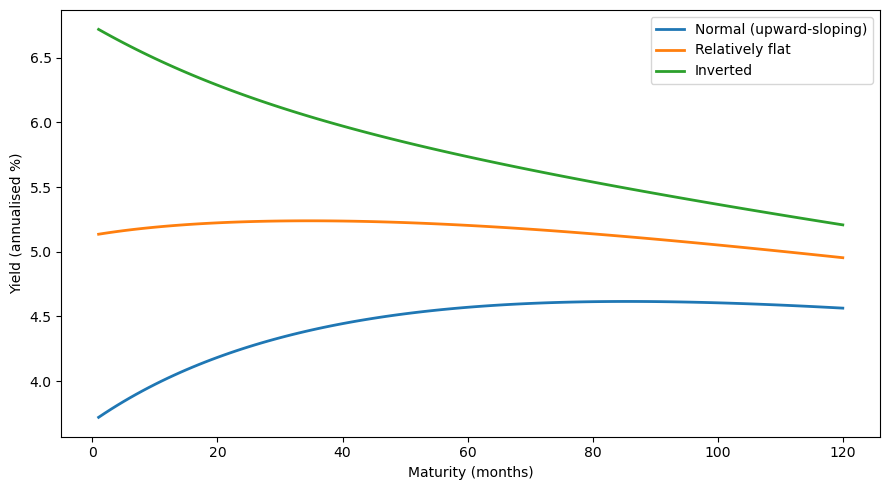

In [5]:
n_max = 120
maturities = np.arange(1, n_max + 1)

states = {
    "Normal (upward-sloping)":  augment_state(np.array([-0.005, -0.015])),
    "Relatively flat":          augment_state(np.array([ 0.008, -0.005])),
    "Inverted":                 augment_state(np.array([ 0.020,  0.010])),
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, x in states.items():
    y = model.yields(x, n_max) * 1200    # annualise (monthly, x1200)
    ax.plot(maturities, y, lw=2, label=label)

ax.set_xlabel("Maturity (months)")
ax.set_ylabel("Yield (annualised %)")
ax.legend()
plt.tight_layout()
plt.show()

### Econometrician's model vs. risk-neutral model

The econometrician estimates state dynamics under the **physical measure** $P$, which governs the actual data-generating process:

$$
x_{t+1} = A x_t + C \varepsilon_{t+1}, \qquad \varepsilon_{t+1} \sim \mathcal{N}(0,I) \text{ under } P
$$

The **risk-neutral measure** $Q$ is the probability distribution twisted by the likelihood ratio $m_{t+1}^\lambda$.

Under $Q$, the state evolves as

$$
x_{t+1} = A_Q x_t + C \tilde\varepsilon_{t+1}, \qquad \tilde\varepsilon_{t+1} \sim \mathcal{N}(0,I) \text{ under } Q
$$

where $A_Q = A - C\lambda$.

The two measures agree on which events are possible but disagree on their probabilities.

The physical measure $P$ governs forecasting and estimation, while the risk-neutral measure $Q$ governs asset pricing.

In [6]:
print("A:\n", model.A)
print("\nA_Q = A - CΛ:\n", model.A_Q)
print(f"\nEigenvalues of check(A):   {eigvals(model.A_core).round(4)}")
print(f"Eigenvalues of check(A_Q): {eigvals(model.A_Q_core).round(4)}")

A:
 [[ 1.    0.    0.  ]
 [ 0.    0.97 -0.03]
 [ 0.    0.    0.9 ]]

A_Q = A - CΛ:
 [[ 1.     0.     0.   ]
 [ 0.     0.991 -0.03 ]
 [ 0.     0.     0.96 ]]

Eigenvalues of check(A):   [0.97 0.9 ]
Eigenvalues of check(A_Q): [0.991 0.96 ]


To see the difference in action, we simulate both models from the same initial state using the same shock sequence.

Both simulations draw the same standard normal random vectors, but the transition matrices $A$ and $A_Q$ govern how those shocks cumulate over time.

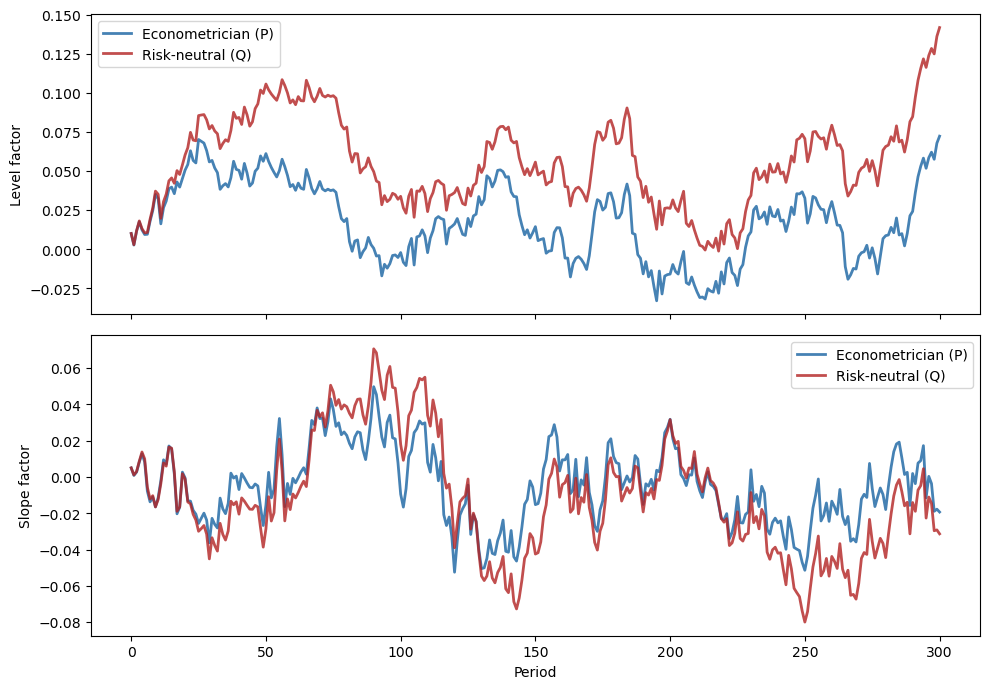

In [7]:
T = 300
x0 = augment_state(np.array([0.01, 0.005]))
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)  # same seed for comparability

X_econ = model.simulate(x0, T, rng=rng1)
X_rn   = model.simulate_twisted(x0, T, rng=rng2)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for idx, (ax, lab) in zip([1, 2], zip(axes, ["Level factor", "Slope factor"])):
    ax.plot(X_econ[:, idx], 'steelblue', lw=2,
            label="Econometrician (P)")
    ax.plot(X_rn[:, idx], 'firebrick', lw=2,
            alpha=0.8, label="Risk-neutral (Q)")
    ax.set_ylabel(lab)
    ax.legend()

axes[1].set_xlabel("Period")
plt.tight_layout()
plt.show()

Both factors are more persistent under $Q$ than under $P$: the eigenvalues of the stochastic block $\check{A}_Q$ are closer to unity than those of $\check{A}$.

The risk-neutral paths (red) exhibit wider swings and slower mean reversion.

This is because the negative risk prices $\lambda$ in our calibration make $A_Q = A - C\lambda$ larger, slowing the rate at which factors revert to zero.

The gap between the $P$ and $Q$ dynamics is precisely what generates a term premium in bond yields, because long bonds are priced under $Q$, where risks look more persistent.

## An identification challenge

The risk price vector $\lambda_t = \lambda  x_t$ can be interpreted as either:

- a **risk price vector** expressing the representative agent's risk aversion, or
- the representative agent's **belief distortion** relative to the econometrician's
  model.

Because the pricing formulas {eq}`eq_stock_lr` to {eq}`eq_ts_lr` depend only on the composite $\lambda_t$, not on whether it reflects risk aversion or belief distortion, the two interpretations produce identical asset prices and econometric fits.

> Relative to the model of a risk-averse representative investor with rational
> expectations, a model of a risk-neutral investor with appropriately mistaken
> beliefs produces *observationally equivalent* predictions.

This insight was articulated by {cite:t}`HST_1999` and
{cite:t}`piazzesi2015trend`.

To distinguish risk aversion from belief distortion, one needs either
*more information* (the PSS approach using survey data) or *more theory*
(the Hansen-Szőke robust control approach), or both (the {cite:t}`szoke2022estimating` approach).

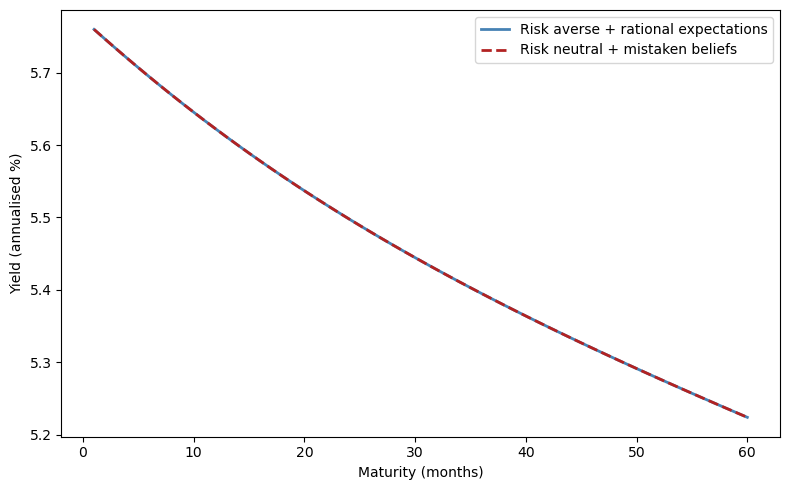

In [8]:
x_test = augment_state(np.array([0.01, 0.005]))
y_risk_averse = model.yields(x_test, 60) * 1200

# Mistaken belief model
model_mistaken = LikelihoodRatioModel(
    A=model.A_Q, C=C, D=D, G=G,
    r_bar=r_bar, Λ=np.zeros_like(Λ)
)
y_mistaken = model_mistaken.yields(x_test, 60) * 1200

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, 61), y_risk_averse, 'steelblue', lw=2,
        label='Risk averse + rational expectations')
ax.plot(np.arange(1, 61), y_mistaken, 'firebrick', lw=2, ls='--',
        label='Risk neutral + mistaken beliefs')
ax.set_xlabel("Maturity (months)")
ax.set_ylabel("Yield (annualised %)")
ax.legend()
plt.tight_layout()
plt.show()

The two yield curves are identical.

Without additional information (e.g., surveys of forecasters), we cannot tell them apart from asset price data alone.


## More information: experts' forecasts (PSS)

### The PSS framework

{cite:t}`piazzesi2015trend` (henceforth PSS) exploit data on professional forecasters' expectations to decompose the likelihood ratio into risk prices and belief distortions.

Their setup posits:

- The representative agent's risk aversion leads him to price risks
  $\varepsilon_{t+1}$ with prices $\lambda_t^* = \lambda^*  x_t$, where $\lambda^*$ is a $k \times n$ matrix.
- The representative agent has **twisted beliefs** $(A^*, C) = (A - C W^*, C)$
  relative to the econometrician's model $(A, C)$, where $W^*$ is a $k \times n$ matrix of belief distortion coefficients, so that $w_t^* = W^* x_t$.
- Professional forecasters use the twisted beliefs $(A^*, C)$ to answer
  survey questions about their forecasts.

### Estimation strategy

PSS proceed in four steps:

1. Use data $\{x_t\}_{t=0}^T$ to estimate the econometrician's model $A$, $C$.
2. Project experts' one-step-ahead forecasts $E_t^*[x_{t+1}]$ on $x_t$ to obtain
   $E_t^*[x_{t+1}] = A^* x_t$ and interpret $A^*$ as incorporating belief
   distortions.
3. Back out the mean distortion matrix from the stochastic block:

   $$
   W^* = -\check{C}^{-1}(A^*_{2:n,\cdot} - A_{2:n,\cdot})
   $$

   so that $w_t^* = W^* x_t$ is the state-dependent mean shift applied to the
   density of $\varepsilon_{t+1}$.  (This requires $\check{C}$ to be invertible.)
4. Reinterpret the $\lambda$ estimated by the rational-expectations econometrician
   as $\lambda = \lambda^* + W^*$, where $\lambda_t^* = \lambda^*  x_t$ is the
   (smaller) price of risk vector actually charged by the representative agent with
   distorted beliefs.

An econometrician who mistakenly imposes rational expectations estimates risk prices $\lambda_t = \lambda  x_t$ that sum two parts:
- *smaller risk prices* $\lambda_t^* = \lambda^*  x_t$ actually charged by the
  representative agent with mistaken beliefs, and
- *conditional mean distortions* $w_t^* = W^*  x_t$ of the risks $\varepsilon_{t+1}$ that
  the twisted-beliefs representative agent's model displays relative to the
  econometrician's.

We illustrate this using a simple numerical example with the same two-factor structure as above.

PSS find that experts perceive the level and slope of the yield curve to be *more persistent* than the econometrician's estimates imply.

Hence we set up the numbers to reflect that finding, with the experts' subjective transition matrix $A^*$ having larger eigenvalues than the econometrician's $A$

In [9]:
A_econ_core = np.array([[0.97, -0.03],
                        [0.00,  0.90]])

A_star_core = np.array([[0.985, -0.025],   # experts' subjective transition
                        [0.000,  0.955]])

C_mat_core = np.array([[0.007, 0.000],
                       [0.000, 0.010]])

A_econ, C_mat, _, _, _ = augment_state_space(
    A_econ_core, C_mat_core, np.zeros((1, 2)), np.zeros((1, 2)), np.zeros(2)
)
A_star, _, _, _, _ = augment_state_space(
    A_star_core, C_mat_core, np.zeros((1, 2)), np.zeros((1, 2)), np.zeros(2)
)

# Belief distortion recovered from the stochastic block
W_star = -np.linalg.solve(C_mat[1:, :], A_star[1:, :] - A_econ[1:, :])

Λ_total = np.hstack([
    np.zeros((2, 1)),
    np.array([[-3.0,  0.0],
              [ 0.0, -6.0]])
])
Λ_true = Λ_total - W_star   # true risk prices

print("Belief distortion W*:\n", W_star.round(3))
print("\nTotal risk prices Λ:\n", Λ_total.round(3))
print("\nTrue risk prices Λ*:\n", Λ_true.round(3))

Belief distortion W*:
 [[-0.    -2.143 -0.714]
 [-0.    -0.    -5.5  ]]

Total risk prices Λ:
 [[ 0. -3.  0.]
 [ 0.  0. -6.]]

True risk prices Λ*:
 [[ 0.    -0.857  0.714]
 [ 0.     0.    -0.5  ]]


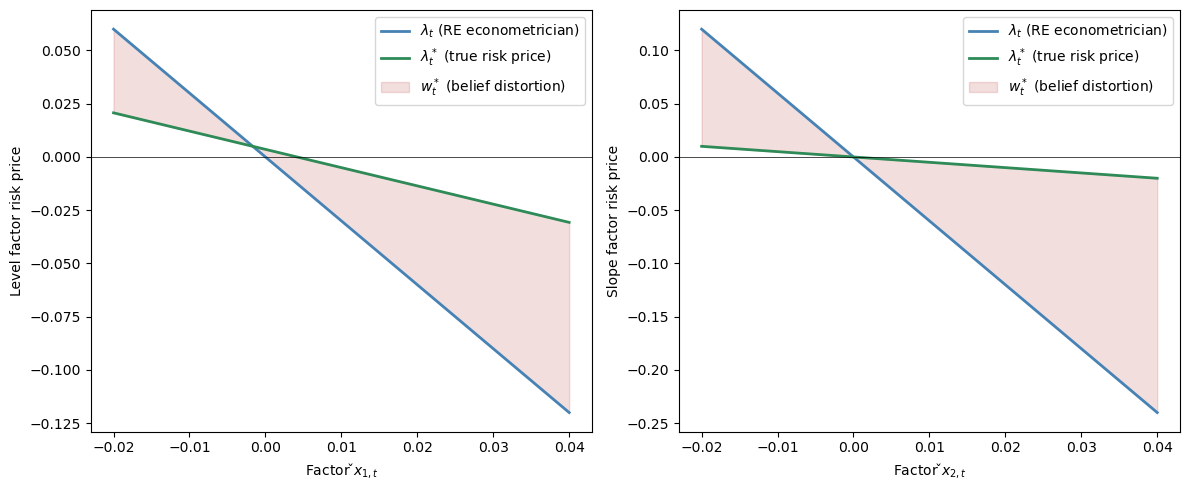

In [10]:
x_grid = np.linspace(-0.02, 0.04, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (ax, lab) in enumerate(zip(axes,
        ["Level factor risk price", "Slope factor risk price"])):
    x_vals = np.ones((200, 3))
    x_vals[:, 1:] = 0.005
    x_vals[:, i + 1] = x_grid

    λ_total = np.array([Λ_total @ x for x in x_vals])[:, i]
    λ_true  = np.array([Λ_true @ x  for x in x_vals])[:, i]

    ax.plot(x_grid, λ_total, 'steelblue', lw=2,
            label=r"$\lambda_t$ (RE econometrician)")
    ax.plot(x_grid, λ_true, 'seagreen', lw=2,
            label=r"$\lambda^*_t$ (true risk price)")
    ax.fill_between(x_grid, λ_true, λ_total, alpha=0.15, color='firebrick',
                    label=r"$w^*_t$ (belief distortion)")
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel(f"Factor $\\check{{x}}_{{{i+1},t}}$")
    ax.set_ylabel(lab)
    ax.legend()

plt.tight_layout()
plt.show()

Subjective risk prices $\lambda^*  x_t$ vary less than the $\lambda  x_t$ estimated by the rational-expectations econometrician.

However, PSS offer no explanation for *why* beliefs are distorted.

Are they mistakes, ignorance of good econometrics, or something else?

## A theory of belief distortions: robust control

The standard justification for rational expectations treats it as the outcome of learning from an infinite history: least-squares learning converges to rational expectations.

That argument requires agents to know correct functional forms and relies on a stochastic approximation argument that partitions dynamics into a fast part (justifying a law of large numbers) and a slow part (justifying an ODE).

However, long intertemporal dependencies make *rates of convergence slow*.

Good econometricians have limited data and only hunches about functional forms, and they fear that their fitted models are incorrect.

An agent who is like a good econometrician:

- has a parametric model estimated from limited data,
- acknowledges that many other specifications fit nearly as well, including other parameter
  values, other functional forms, omitted variables, neglected nonlinearities,
  and history dependencies,
- fears that one of those other models actually prevails, and
- seeks "good enough" decisions under *all* such alternative models, i.e. **robustness**.

Robust control theory formalises this idea by having the agent optimally distort probability assessments toward a worst-case scenario, producing belief distortions that look like the "mistakes" identified by PSS but that arise from a coherent response to model uncertainty rather than from ignorance.

### Hansen's dubious agent

Inspired by robust control theory, consider a dubious investor who:

- shares the econometrician's model $A$, $C$, $D$, $G$,
- expresses doubts by using a continuum of likelihood ratios to form a **discounted
  entropy ball** of size $\eta$ around the econometrician's model,
- wants a valuation that is good for every model in the entropy ball, and
- constructs a *lower bound* on values and a *worst-case model* that attains it.

Under the econometrician's linear Gaussian model with shocks $\varepsilon_{t+1} \sim \mathcal{N}(0,I)$:

$$
c_{t+1} - c_t = D x_t + G \varepsilon_{t+1}, \qquad x_{t+1} = A x_t + C \varepsilon_{t+1}
$$

the dubious agent's value function is

$$
V(x_0, c_0) := E \left[\sum_{t=0}^{\infty} \beta^t c_t  \middle|  x_0, c_0\right] = c_0 + \beta E \left[V(x_1, c_1)  \middle|  x_0, c_0\right]
$$

Note that the objective is *linear* in consumption.

There is no concave utility function $u(c_t)$.

All aversion to uncertainty here comes from the *worst-case model selection* (the $\min$ over likelihood ratios below), not from utility curvature.

This separation is a key feature of the robust control approach: the agent expresses doubt through the entropy ball, rather than through a curved utility function.

### The sequence problem

The dubious agent solves a *min* problem in which a malevolent "nature" chooses the worst-case probability distortion subject to an entropy budget.

Nature's instrument is a sequence of one-step likelihood ratios $m_{t+1}$, each of which distorts the conditional distribution of $\varepsilon_{t+1}$ given information at $t$.

These increments cumulate into a date-$t$ likelihood ratio $M_t = \prod_{s=0}^{t-1} m_{s+1}$ (with $M_0 = 1$) that converts the econometrician's probability measure into the distorted one.

The objective, evaluated under the econometrician's measure, weights each period's consumption by $M_t$:

```{math}
:label: eq_hansen_seq

J(x_0, c_0 \mid \eta) := \min_{\{m_{t+1}\}} E \left[\sum_{t=0}^{\infty} \beta^t M_t c_t  \middle|  x_0, c_0\right]
```

The minimisation is subject to three sets of constraints.

First, the economy evolves according to the econometrician's model:

$$
c_{t+1} - c_t = D x_t + G \varepsilon_{t+1}, \qquad x_{t+1} = A x_t + C \varepsilon_{t+1}
$$

Second, nature's total probability distortion, measured by discounted entropy, must remain within a budget $\eta$:

$$
E \left[\sum_{t=0}^{\infty} \beta^t M_t E \left[m_{t+1}\log m_{t+1}  \middle|  x_t, c_t\right]  \middle|  x_0, c_0\right] \leq \eta
$$

Third, the incremental likelihood ratios must be valid probability distortions that cumulate multiplicatively:

$$
M_{t+1} = M_t m_{t+1}, \qquad E[m_{t+1} \mid x_t, c_t] = 1, \qquad M_0 = 1
$$

The cumulative likelihood ratio $M_t = \prod_{s=0}^{t-1} m_{s+1}$ converts the original probability measure into the distorted one.

The $M_t$ weighting ensures entropy is measured under the *distorted* measure and the $\beta^t$ discounting means future divergences are penalised less, admitting persistent alternatives.

The likelihood ratio process $\{M_t\}_{t=0}^{\infty}$ is a multiplicative **martingale**.

```{figure} /_static/lecture_specific/risk_aversion_or_mistaken_beliefs/eggs_backus.png
Discounted entropy ball around the econometrician's model.
```

### Why discounted entropy?

Discounted entropy includes models that undiscounted entropy excludes.

Undiscounted entropy over infinite sequences requires alternative models to share the same long-run averages as the baseline, thereby excluding models that differ only in persistent, low-frequency dynamics.

But those persistent alternatives are precisely the models that are hardest to distinguish from the econometrician's model with finite data and that matter most for pricing long-lived assets.

Discounted entropy, by treating future divergences less severely, admits these statistically elusive but economically important alternatives into the set of models that the dubious agent contemplates.

### Entropy and the likelihood ratio

When the likelihood ratio takes the log-normal form used throughout this lecture, entropy simplifies dramatically.

Writing the one-step likelihood ratio in terms of a distortion vector $w_t$:

$$
m_{t+1} := \exp \left(-\frac{w_t^\top w_t}{2} - w_t^\top \varepsilon_{t+1}\right)
$$

and computing $E[m_{t+1}\log m_{t+1} \mid x_t]$, the cross term $w_t^\top \varepsilon_{t+1}$ averages to zero, leaving only:

$$
E \left[m_{t+1}\log m_{t+1}  \middle|  x_t, c_t\right] = \frac{1}{2} w_t^\top w_t
$$

This means that conditional entropy equals half the squared norm of the distortion vector — it measures how far the distorted mean $-w_t$ is from the baseline mean of zero.

Substituting this expression into {eq}`eq_hansen_seq` and performing a change of measure (replacing $E[\cdot]$ with $E^w[\cdot]$ under the distorted model) yields a reformulated problem in which nature directly chooses the mean shift $w_t$ rather than a likelihood ratio:

```{math}
:label: eq_hansen_reform

J(x_0, c_0 \mid \eta) := \min_{\{w_t\}} E^w \left[\sum_{t=0}^{\infty} \beta^t c_t  \middle|  x_0, c_0\right]
```

Under the distorted measure, $\tilde\varepsilon_{t+1} \sim \mathcal{N}(0, I)$, and we have substituted $\varepsilon_{t+1} = \tilde\varepsilon_{t+1} - w_t$ so that the mean shift $-w_t$ appears explicitly in the dynamics:

$$
c_{t+1} - c_t = D x_t + G (\tilde\varepsilon_{t+1} - w_t), \qquad x_{t+1} = A x_t + C (\tilde\varepsilon_{t+1} - w_t)
$$

The entropy constraint now takes the transparent form of bounding the cumulative squared distortion:

$$
\frac{1}{2} E^w \left[\sum_{t=0}^{\infty} \beta^t w_t^\top w_t  \middle|  x_0, c_0\right] \leq \eta
$$

The shift $-w_t$ *reduces* expected consumption growth by $G w_t$ and shifts the state dynamics by $-C w_t$, which is how the worst-case model makes the agent worse off.

### Outcome: constant worst-case distortion

Because the econometrician's model is linear Gaussian and the entropy constraint is a scalar bound $\eta$, the worst-case mean distortion turns out to be a *constant vector*:

$$
w_t = \bar{w}
$$

The consequence is that the contribution of $w_t$ to risk prices is *state-independent*.

This does *not* help explain countercyclical prices of risk (or prices of model uncertainty), motivating the more refined "tilted" entropy ball in the next section.

We compute $\bar{w}$ using the multiplier formulation developed in {ref}`the preceding section <mult_pref_section>`, in which the parameter $\theta$ penalises entropy: larger $\theta$ means less concern about misspecification.

In the multiplier formulation, the agent minimises

$$
E^w \left[\sum_{t=0}^\infty \beta^t \bigl(c_t + \tfrac{\theta}{2} w_t^\top w_t\bigr)\right]
$$

over $\{w_t\}$ subject to the shifted dynamics.

Since $c_t = c_0 + \sum_{s=0}^{t-1}(D x_s + G \varepsilon_{s+1})$ and $\varepsilon_{s+1} = \tilde\varepsilon_{s+1} - w_s$, the first-order condition for $w_t$ balances the entropy penalty $\theta  w_t$ against the marginal effect on discounted consumption:

$$
\theta \bar{w} = \frac{\beta}{1-\beta} G^\top + \beta C^\top v
$$

where $v$ solves $v = \frac{\beta}{1-\beta} D^\top + \beta A^\top v$, or equivalently $v = \beta (I - \beta A^\top)^{-1} D^\top / (1-\beta)$.

The vector $v$ captures the discounted cumulative effect of a unit change in $x_t$ on future consumption.

In [11]:
def hansen_worst_case(A, C, D, G, β, θ):
    """Constant worst-case distortion w_bar for Hansen's dubious agent."""
    n = A.shape[0]
    v = β * np.linalg.solve(np.eye(n) - β * A.T, D.T.flatten()) / (1 - β)
    w_bar = (1.0 / θ) * (β / (1 - β) * G.T.flatten() + β * C.T @ v)
    return w_bar


β = 0.995
θ_values = [0.5, 1.0, 2.0, 5.0]

print(f"{'θ':>6}  {'w_bar[0]':>10}  {'w_bar[1]':>10}  {'Entropy':>10}")
print("-" * 42)
for θ in θ_values:
    w = hansen_worst_case(A, C, D, G, β, θ)
    print(f"{θ:>6.1f}  {w[0]:>10.4f}  {w[1]:>10.4f}  {0.5 * w @ w:>10.4f}")

     θ    w_bar[0]    w_bar[1]     Entropy
------------------------------------------
   0.5     41.3634     -3.6667    862.1896
   1.0     20.6817     -1.8333    215.5474
   2.0     10.3409     -0.9167     53.8869
   5.0      4.1363     -0.3667      8.6219


The worst-case distortion $\bar{w}$ is constant: it does not depend on the state $x_t$.

Larger $\theta$ (less concern about misspecification) yields a smaller distortion.

````{exercise}
:label: lr_exercise_2

Derive the formula for $\bar{w}$.

1. Write the discounted consumption path as $\sum_{t=0}^\infty \beta^t c_t = \frac{c_0}{1-\beta} + \sum_{t=0}^\infty \beta^t \sum_{s=0}^{t-1}(D x_s - G w_s + G \tilde\varepsilon_{s+1})$.
2. Use the state recursion $x_{t+1} = A x_t - C w_t + C \tilde\varepsilon_{t+1}$ and take first-order conditions with respect to the constant $w_t = \bar{w}$.
3. Verify that the first-order condition gives $\theta \bar{w} = \frac{\beta}{1-\beta} G^\top + \beta C^\top v$ with $v = \beta(I - \beta A^\top)^{-1} D^\top / (1-\beta)$.
4. Check numerically that larger $\theta$ brings $\bar{w}$ closer to zero.

````

````{solution} lr_exercise_2
:class: dropdown

For part 1, the consumption increment $\Delta c_{s+1} = Dx_s - G\bar{w} + G\tilde\varepsilon_{s+1}$ at date $s$ enters $c_t$ for every $t \geq s+1$, with total discounted weight $\frac{\beta^{s+1}}{1-\beta}$.

Swapping the order of summation:

$$
E \left[\sum_{t=0}^\infty \beta^t c_t\right] = \frac{c_0}{1-\beta} + \frac{1}{1-\beta}\sum_{s=0}^\infty \beta^{s+1}\bigl(D  E[x_s] - G\bar{w}\bigr)
$$

For part 2, define $S = \sum_{s=0}^\infty \beta^{s+1} E[x_s]$.

From $E[x_{s+1}] = A E[x_s] - C\bar{w}$, multiply both sides by $\beta^{s+2}$ and sum over $s = 0, 1, \ldots$:

$$
S - \beta x_0 = \beta A  S - \frac{\beta^2}{1-\beta}C\bar{w}
$$

Solving: $S = (I - \beta A)^{-1} \left(\beta x_0 - \frac{\beta^2}{1-\beta}C\bar{w}\right)$.

Substituting back, the expected objective $E[\sum \beta^t(c_t + \frac{\theta}{2}\|\bar{w}\|^2)]$ depends on $\bar{w}$ only through the term $\frac{1}{1-\beta}(D S - \frac{\beta}{1-\beta}G\bar{w}) + \frac{\theta}{2(1-\beta)}\|\bar{w}\|^2$.

For part 3, differentiate with respect to $\bar{w}$ and set to zero.

The only part of $S$ that depends on $\bar{w}$ is $-\frac{\beta^2}{1-\beta}(I-\beta A)^{-1}C\bar{w}$, so $\nabla_{\bar{w}}(D S) = -\frac{\beta^2}{1-\beta}C^\top(I - \beta A^\top)^{-1}D^\top$.

The first-order condition is:

$$
\frac{\theta}{1-\beta}\bar{w} = \frac{1}{1-\beta} \left(\frac{\beta}{1-\beta}G^\top + \frac{\beta^2}{1-\beta}C^\top(I - \beta A^\top)^{-1}D^\top\right)
$$

Simplifying: $\theta\bar{w} = \frac{\beta}{1-\beta}G^\top + \beta C^\top v$, where $v = \frac{\beta}{1-\beta}(I - \beta A^\top)^{-1}D^\top$.

Therefore $\bar{w} = \frac{1}{\theta}\bigl(\frac{\beta}{1-\beta}G^\top + \beta C^\top v\bigr)$.

For part 4, as $\theta \to \infty$, $\bar{w} = \frac{1}{\theta}(\cdots) \to 0$, which the numerical table confirms.

````

(mult_pref_section)=
## Multiplier preferences

The constraint formulation {eq}`eq_hansen_seq` bounds discounted entropy by $\eta$, but an equivalent **multiplier** formulation replaces the constraint with a penalty term weighted by a Lagrange multiplier $\theta$.

The **multiplier preference** version of the dubious agent's problem is:

```{math}
:label: eq_mult_seq

\hat{J}(x_0, c_0 \mid \theta) := \min_{\{m_{t+1}\}} E \left[\sum_{t=0}^{\infty} \beta^t M_t\bigl(c_t + \theta m_{t+1}\log m_{t+1}\bigr)  \middle|  x_0, c_0\right]
```

with $M_{t+1} = M_t m_{t+1}$, $E[m_{t+1} \mid x_t, c_t] = 1$, $M_0 = 1$.

To derive a Bellman equation, write the value as today's consumption plus the worst-case continuation:

$$
\hat{J}(x_t, c_t \mid \theta) = c_t + \min_{m_{t+1}} E \left[m_{t+1}\bigl[\beta \hat{J}(x_{t+1}, c_{t+1}) + \theta\log m_{t+1}\bigr]  \middle|  x_t, c_t\right]
$$

Solving the inner minimisation analytically (by completing the square in the exponential family) yields a closed-form expression:

$$
= c_t - \theta\log E \left[\exp \left(-\frac{\beta \hat{J}(x_{t+1}, c_{t+1})}{\theta}\right)  \middle|  x_t, c_t\right]
$$

The second line defines the **risk-sensitivity operator** $T_t$:

$$
=: c_t + T_t \left[\beta \hat{J}(x_{t+1}, c_{t+1})\right]
$$

The minimising likelihood ratio that attains this value is:

$$
m_{t+1}^* \propto \exp \left(-\frac{\beta \hat{J}(x_{t+1}, c_{t+1})}{\theta}\right)
$$

By Lagrange multiplier theory, for the **corresponding dual pair** $(\tilde\theta, \eta)$,

$$
\hat{J}(x_t, c_t \mid \tilde\theta) = J(x_t, c_t \mid \eta) + \tilde\theta \eta
$$

Each choice of $\tilde\theta$ in the multiplier problem corresponds to a particular entropy bound $\eta(\tilde\theta)$ in the constraint problem, so the two formulations are equivalent.

The operator $T_t$ defined above is a **risk-sensitivity operator** that maps the continuation value through an exponential tilt, downweighting good outcomes and upweighting bad ones.

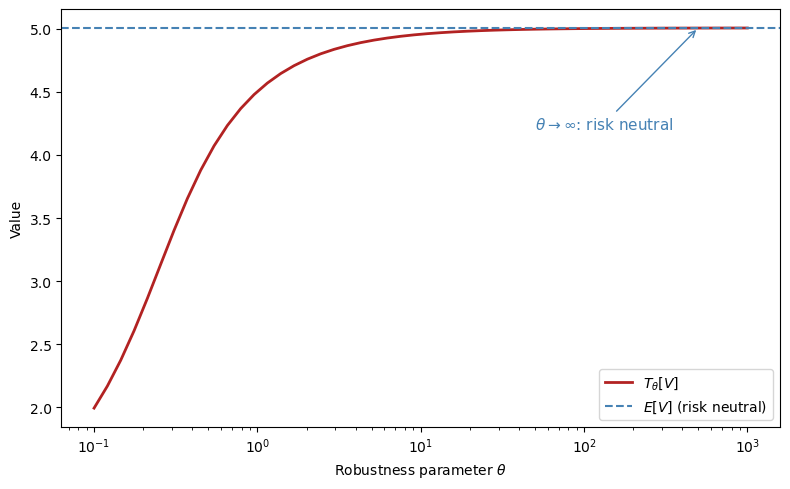

In [12]:
def T_operator(V, θ, probs=None):
    """Risk-sensitivity operator: T[V] = -θ log E[exp(-V/θ)]."""
    if probs is None:
        probs = np.ones(len(V)) / len(V)
    V_s = -V / θ
    max_v = np.max(V_s)
    return -θ * (max_v + np.log(np.sum(probs * np.exp(V_s - max_v))))

rng = np.random.default_rng(0)
V_samples = rng.normal(loc=5.0, scale=1.0, size=10_000)
E_V = np.mean(V_samples)

θ_grid = np.logspace(-1, 3, 50)
T_vals = [T_operator(V_samples, θ) for θ in θ_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(θ_grid, T_vals, 'firebrick', lw=2, label=r"$T_\theta[V]$")
ax.axhline(E_V, color='steelblue', lw=1.5,
           ls='--', label=r"$E[V]$ (risk neutral)")
ax.set_xlabel(r"Robustness parameter $\theta$")
ax.set_ylabel("Value")
ax.legend()
ax.annotate(r"$\theta \to \infty$: risk neutral",
            xy=(500, E_V), fontsize=11, color='steelblue',
            xytext=(50, E_V - 0.8),
            arrowprops=dict(arrowstyle='->', color='steelblue'))
plt.tight_layout()
plt.show()

As $\theta \to \infty$, the risk-sensitivity operator converges to the ordinary expectation $E[V]$, and the agent becomes risk neutral.

As $\theta$ shrinks, the operator places more weight on bad outcomes, reflecting greater concern about model misspecification.

## Tilting the entropy ball

### Hansen and Szőke's more refined dubious agent

To generate *state-dependent* uncertainty prices, Hansen and Szőke introduce a more refined dubious agent who:

- shares the econometrician's model $A$, $C$, $D$, $G$,
- expresses doubts by using a continuum of likelihood ratios to form a
  discounted entropy ball around the econometrician's model, *and*
- also insists that some martingales representing particular alternative
  *parametric* models be included in the discounted entropy ball.

The inclusion of those alternative parametric models *tilts* the entropy ball, which affects the worst-case model in a way that can produce countercyclical uncertainty prices.

"Tilting" means replacing the constant entropy bound $\eta$ with a state-dependent bound $\xi(x_t)$ that is larger in states where the feared parametric alternative deviates more from the baseline.

### The feared parametric model

The investor wants the entropy ball to be large enough to include specific alternative models whose conditional entropy at each date is:

$$
E_t \left[\bar{m}_{t+1}\log\bar{m}_{t+1}\right] = \frac{1}{2} \bar{w}_t^\top \bar{w}_t =: \frac{1}{2}\xi(x_t)
$$

The function $\xi(x_t)$ measures how far the feared model's conditional distribution deviates from the baseline at state $x_t$, and the total discounted divergence of the feared model is:

$$
\frac{1}{2} E^{\bar{W}} \left[\sum_{t=0}^{\infty} \beta^t \xi(x_t)  \middle|  x_0, c_0\right]
$$

To ensure this feared model lies inside the entropy ball, we replace the earlier constant bound $\eta$ with a state-dependent budget:

```{math}
:label: eq_tilted_constraint

\frac{1}{2} E^w \left[\sum_{t=0}^{\infty} \beta^t w_t^\top w_t  \middle|  x_0, c_0\right] \leq \frac{1}{2} E^w \left[\sum_{t=0}^{\infty} \beta^t \xi(x_t)  \middle|  x_0, c_0\right]
```

The time-$t$ contributions to the right-hand side of {eq}`eq_tilted_constraint` relax the discounted entropy constraint in states $x_t$ in which $\xi(x_t)$ is larger.

This sets the stage for *state-dependent* mean distortions in the worst-case model.

Inspired by {cite:t}`Bansal_Yaron_2004`, a concrete form of this concern is that the true state dynamics are more persistent than the econometrician's model implies, expressed by

$$
x_{t+1} = \bar{A} x_t + C \tilde\varepsilon_{t+1}
$$

Since $\bar{A} = A - C\bar{W}$, this feared model is equivalent to shifting the mean of $\varepsilon_{t+1}$ by $-\bar{W}x_t$, giving $\bar{w}_t = \bar{W} x_t$ with

$$
\bar{W} = -\check{C}^{-1}(\bar{A}_{2:n,\cdot} - A_{2:n,\cdot})
$$

(again using the assumption that $\check{C}$ is square and invertible), which implies a *quadratic* $\xi$ function:

```{math}
:label: eq_xi

\xi(x_t) := x_t^\top \bar{W}^\top\bar{W} x_t =: x_t^\top \Xi x_t
```

```{figure} /_static/lecture_specific/risk_aversion_or_mistaken_beliefs/eggs_backus2.png
Tilted discounted entropy balls. Including particular parametric alternatives with more long-run risk tilts the entropy ball and generates state-dependent worst-case distortions.
```

### The Szőke agent's sequence problem

As in the multiplier preferences section, we convert the constraint problem into an unconstrained one by attaching a Lagrange multiplier $\tilde\theta \geq 0$ to the tilted entropy constraint {eq}`eq_tilted_constraint`.

The penalty $\tilde\theta(w_t^\top w_t - x_t^\top \Xi x_t)/2$ now has two terms: the first penalises the agent's distortion, while the second rewards distortions in states where the feared model deviates more, creating a state-dependent entropy budget:

```{math}
:label: eq_szoke_seq

J(x_0, c_0 \mid \Xi) := \max_{\tilde\theta \geq 0} \min_{\{w_t\}}  E^w \left[\sum_{t=0}^{\infty} \beta^t c_t + \tilde\theta \frac{1}{2}\sum_{t=0}^{\infty} \beta^t\bigl(w_t^\top w_t - x_t^\top \Xi x_t\bigr)  \middle|  x_0, c_0\right]
```

The dynamics under the distorted measure remain linear Gaussian:

$$
c_{t+1} - c_t = D x_t + G (\tilde\varepsilon_{t+1} - w_t), \qquad x_{t+1} = A x_t + C (\tilde\varepsilon_{t+1} - w_t)
$$

Because the state vector now includes a leading constant $1$, we can write the worst-case distortion as a *linear* function of the augmented state:

$$
\tilde{w}_t = \tilde{W} x_t
$$

The first column of $\tilde{W}$ stores the constant part that would otherwise be written separately as $a$, while the remaining columns load on the stochastic factors $\check{x}_t$.

When $\Xi = 0$ (no tilting), that first column reduces to Hansen's constant $\bar{w}$ from the untilted problem, while the remaining columns are zero.

When $\Xi \neq 0$, the nonconstant columns of $\tilde{W}$ are the new contribution of the tilted entropy ball, and are what generate countercyclical uncertainty prices.

Writing $\tilde{A} = A - C \tilde{W}$ and $\tilde{D} = D - G \tilde{W}$, the worst-case dynamics are

$$
x_{t+1} = \tilde{A} x_t + C\tilde\varepsilon_{t+1}, \qquad c_{t+1} - c_t = \tilde{D} x_t + G\tilde\varepsilon_{t+1}
$$

### Implementation: tilted entropy ball

For the inner minimisation over $\{w_t\}$ in {eq}`eq_szoke_seq`, the value function is **affine-quadratic** in the augmented state because $c_t$ enters linearly:

$$
J(x, c) = \frac{c}{1-\beta} + v^\top x + x^\top P x + K
$$

Writing $e_1 = (1, 0, \ldots, 0)^\top$ for the selector of the constant state and $\tilde\theta$ as $\theta$ in the code, the first-order condition for $\tilde{W}$ balances the entropy penalty against the marginal effects on the value function:

$$
(\theta I + 2\beta C^\top P C) \tilde{W}
= 2\beta C^\top P A
+ \left(\frac{\beta}{1-\beta} G^\top + \beta C^\top v\right) e_1^\top
$$

The linear coefficient $v$ captures the discounted cumulative effect of a unit change in $x_t$ on future consumption, and satisfies:

$$
\bigl(I - \beta (A - C\tilde{W})^\top\bigr) v
= \frac{\beta}{1-\beta} \left(D^\top - \tilde{W}^\top G^\top\right)
$$

Finally, matching quadratic terms in $x$ yields the matrix Riccati equation for $P$, which encodes the curvature of the value function:

$$
P = -\tfrac{\theta}{2} \Xi + \tfrac{\theta}{2} \tilde{W}^\top \tilde{W} + \beta (A - C\tilde{W})^\top P (A - C\tilde{W})
$$

The code below iterates on the coupled $(P, v, \tilde{W})$ system to convergence.

For later comparisons, we also keep a version of $\tilde{W}$ with its first column set to zero, denoted informally by $\tilde{W}^{sd}$, which isolates the factor-dependent component.

In [13]:
class TiltedEntropyModel:
    """
    Hansen-Szőke tilted entropy ball model.

    Given (A, C, D, G, β, θ, Ξ), computes the full worst-case
    distortion matrix W_tilde in w_t = W_tilde @ x_t.

    The first column of W_tilde is the constant component induced by
    the augmented state x_t = [1, check_x_t']'. W_tilde_state zeros
    that column out and keeps only factor-dependent loadings.
    """

    def __init__(self, A, C, D, G, β, θ, Ξ):
        self.A = np.atleast_2d(A).astype(float)
        self.C = np.atleast_2d(C).astype(float)
        self.D = np.atleast_2d(D).astype(float)
        self.G = np.atleast_2d(G).astype(float)
        self.β, self.θ = float(β), float(θ)
        self.Ξ = np.atleast_2d(Ξ).astype(float)
        self.n = self.A.shape[0]

        self.W_tilde, self.v = self._solve_worst_case()
        self.A_tilde = self.A - self.C @ self.W_tilde
        self.D_tilde = self.D - self.G @ self.W_tilde
        self.W_tilde_state = self.W_tilde.copy()
        self.W_tilde_state[:, 0] = 0.0
        self.A_tilde_state = self.A - self.C @ self.W_tilde_state
        self.D_tilde_state = self.D - self.G @ self.W_tilde_state

    def _solve_worst_case(self):
        """Iterate on the coupled (P, v, W) system."""
        n, k = self.n, self.C.shape[1]
        β, θ = self.β, self.θ

        P = np.zeros((n, n))
        v = np.zeros(n)
        e1 = np.zeros(n)
        e1[0] = 1.0
        converged = False
        for _ in range(10000):
            M = θ * np.eye(k) + 2 * β * self.C.T @ P @ self.C
            b = β / (1 - β) * self.G.T.flatten() + β * self.C.T @ v
            rhs = 2 * β * self.C.T @ P @ self.A + np.outer(b, e1)
            W = np.linalg.solve(M, rhs)
            A_w = self.A - self.C @ W
            P_new = (-(θ / 2) * self.Ξ
                    + (θ / 2) * W.T @ W
                    + β * A_w.T @ P @ A_w)
            P_new = 0.5 * (P_new + P_new.T)
            D_flat = self.D.T.flatten()
            G_flat = self.G.T.flatten()
            rhs_v = β * (D_flat - W.T @ G_flat) / (1 - β)
            v_new = np.linalg.solve(np.eye(n) - β * A_w.T, rhs_v)
            if (np.max(np.abs(P_new - P)) < 1e-10
                    and np.max(np.abs(v_new - v)) < 1e-10):
                P = P_new
                v = v_new
                converged = True
                break
            P = P_new
            v = v_new

        if not converged:
            print("Warning: (P, v, W) iteration did not converge")
        self._P_quad = P
        self._v_lin = v
        return W, v

    def distortion(self, x):
        """Full worst-case distortion W_tilde @ x."""
        return self.W_tilde @ x

    def state_dependent_distortion(self, x):
        """Factor-dependent component with the constant column removed."""
        return self.W_tilde_state @ x

    def entropy(self, x):
        """Full conditional entropy: (1/2)(W_tilde x)'(W_tilde x)."""
        w = self.distortion(x)
        return 0.5 * w @ w

    def state_dependent_entropy(self, x):
        """Entropy of the factor-dependent component only."""
        w = self.state_dependent_distortion(x)
        return 0.5 * w @ w

    def xi_function(self, x):
        return x @ self.Ξ @ x

In [14]:
# Feared parametric model
A_bar_core = np.array([[0.995, -0.03],
                       [0.000,  0.96]])

A_bar, _, _, _, _ = augment_state_space(
    A_bar_core, C_core, np.zeros((1, 2)), np.zeros((1, 2)), np.zeros(2)
)

W_bar = -np.linalg.solve(C[1:, :], A_bar[1:, :] - A[1:, :])
Ξ = W_bar.T @ W_bar

print("Feared transition A_bar:\n", A_bar)
print("\nImplied distortion W_bar:\n", W_bar.round(3))
print("\nTilting matrix Ξ:\n", Ξ.round(1))

Feared transition A_bar:
 [[ 1.     0.     0.   ]
 [ 0.     0.995 -0.03 ]
 [ 0.     0.     0.96 ]]

Implied distortion W_bar:
 [[-0.    -3.571 -0.   ]
 [-0.    -0.    -6.   ]]

Tilting matrix Ξ:
 [[ 0.   0.   0. ]
 [ 0.  12.8  0. ]
 [ 0.   0.  36. ]]


In {eq}`eq_szoke_seq` the multiplier $\tilde\theta$ is determined by the outer maximisation.  

Here we fix $\theta$ at a representative value and solve only the inner minimisation, illustrating the multiplier formulation described in {ref}`the multiplier preferences section <mult_pref_section>`.

In [15]:
θ_tilt = 3.0
tilted = TiltedEntropyModel(A, C, D, G, β, θ_tilt, Ξ)

print("Worst-case distortion W_tilde:\n", tilted.W_tilde.round(4))
print("\nConstant column of W_tilde:\n", tilted.W_tilde[:, 0].round(4))
W_fd = tilted.W_tilde[:, 1:].round(4)
print("\nFactor-dependent columns of W_tilde:\n", W_fd)
print("\nWorst-case transition A_tilde:\n",
      tilted.A_tilde.round(4))
eig_A = eigvals(A[1:, 1:]).round(4)
eig_At = eigvals(tilted.A_tilde[1:, 1:]).round(4)
print(f"\nEigenvalues of check(A):       {eig_A}")
print(f"Eigenvalues of check(A_tilde): {eig_At}")

Worst-case distortion W_tilde:
 [[11.705  -1.7572  0.5461]
 [-4.0648  0.7572 -2.1579]]

Constant column of W_tilde:
 [11.705  -4.0648]

Factor-dependent columns of W_tilde:
 [[-1.7572  0.5461]
 [ 0.7572 -2.1579]]

Worst-case transition A_tilde:
 [[ 1.      0.      0.    ]
 [-0.0819  0.9823 -0.0338]
 [ 0.0406 -0.0076  0.9216]]

Eigenvalues of check(A):       [0.97 0.9 ]
Eigenvalues of check(A_tilde): [0.9863 0.9176]


````{exercise}
:label: lr_exercise_3

Derive the first-order condition for the tilted entropy problem under the augmented-state convention.

1. Start from {eq}`eq_szoke_seq` and write $w_t = W x_t$, where the first column of $W$ captures the constant part of the distortion.
2. Show that the first-order condition gives

   $$
   (\theta I + 2\beta C^\top P C) W
   = 2\beta C^\top P A
   + \left(\frac{\beta}{1-\beta} G^\top + \beta C^\top v\right)e_1^\top
   $$

   and derive the associated linear equation for $v$.
3. Derive the $P$ update by substituting the optimal $W$ back into the Bellman equation and matching quadratic terms in $x$.

````

````{solution} lr_exercise_3
:class: dropdown

For part 1, write $w_t = W x_t$ with $x_t = (1, \check{x}_t^\top)^\top$.

To confirm the affine-quadratic form, substitute this guess into the Bellman equation for the inner minimisation of {eq}`eq_szoke_seq`:

$$
J(x, c) = \min_{w} \left\{ c + \frac{\theta}{2}(w^\top w - x^\top \Xi x) + \beta\, E\bigl[J(x', c')\bigr] \right\}
$$

where $x' = Ax + C(\tilde\varepsilon - w)$ and $c' - c = Dx + G(\tilde\varepsilon - w)$.

Conjecture $J(x,c) = c/(1-\beta) + v^\top x + x^\top P x + K$.

Under this guess, $J(x',c') = c'/(1-\beta) + v^\top x' + x'^\top P x' + K$.

Write $c'/(1-\beta) = c/(1-\beta) + (c'-c)/(1-\beta)$, so the $c/(1-\beta)$ term passes through both sides and can be cancelled.

Substituting $w = Wx$, the next-period state is $x' = (A - CW)x + C\tilde\varepsilon$, and the consumption increment is $(c'-c) = (D - GW)x + G\tilde\varepsilon$.

Taking $E[\cdot]$ (with $E[\tilde\varepsilon] = 0$, $E[\tilde\varepsilon\tilde\varepsilon^\top] = I$), the right-hand side after cancelling $c/(1-\beta)$ has the following structure.

*Quadratic terms in $x$:*

$$
-\tfrac{\theta}{2} x^\top \Xi x + \tfrac{\theta}{2} x^\top W^\top W x + \beta x^\top (A-CW)^\top P (A-CW) x
$$

These come from the penalty $\frac{\theta}{2}(w^\top w - x^\top \Xi x)$ and from $x'^\top P x'$.

*Linear terms in $x$:*

$$
\tfrac{\beta}{1-\beta}(D - GW)x + \beta v^\top (A-CW)x
$$

These come from $(c'-c)/(1-\beta)$ and from $v^\top x'$.

The remaining terms are constant (independent of $x$).

These come from the noise terms and from $K$.

Every term is at most quadratic in $x$, so matching coefficients reproduces the conjectured form $v^\top x + x^\top P x + K$ with updated $v$, $P$, $K$.

This confirms self-consistency of the affine-quadratic guess.

To derive the first-order condition, collect all terms in the Bellman RHS that depend on $w = Wx$.

From the penalty $\frac{\theta}{2} w^\top w$, the contribution is $\frac{\theta}{2}x^\top W^\top W x$.

From $\beta E[v^\top x']$ with $E[x'] = (A-CW)x$, the $w$-dependent part is $-\beta v^\top C W x$.

From $\beta E[(c'-c)/(1-\beta)]$ with $E[c'-c] = (D-GW)x$, the $w$-dependent part is $-\frac{\beta}{1-\beta} G W x$.

From $\beta E[x'^\top P x']$ with $E[x'] = (A-CW)x$, the $w$-dependent part is $\beta x^\top (A-CW)^\top P (A-CW) x$.

Differentiating with respect to $W$ and using $e_1^\top x_t = 1$ gives:

$$
(\theta I + 2\beta C^\top P C) W
= 2\beta C^\top P A
+ \left(\frac{\beta}{1-\beta} G^\top + \beta C^\top v\right)e_1^\top
$$

This shows directly how the first column of $W$ carries the constant part of the distortion.

$$
\bigl(I - \beta (A - CW)^\top\bigr) v
= \frac{\beta}{1-\beta} \left(D^\top - W^\top G^\top\right)
$$

This is the linear equation used in the code to update $v$ once $W$ is known.

For part 3, substitute the optimal $W$ back into the Bellman equation.

The quadratic terms in $x_t$ give:

$$
P = -\tfrac{\theta}{2} \Xi + \tfrac{\theta}{2} W^\top W + \beta (A-CW)^\top P(A-CW)
$$

This is the matrix Riccati equation that the code iterates to convergence.

````

### State-dependent entropy: the key innovation

The following figure compares the conditional entropy of the worst-case distortion across three models as a function of the level factor $\check{x}_{1,t}$, revealing how the tilted entropy ball produces the state dependence that Hansen's original formulation lacks.

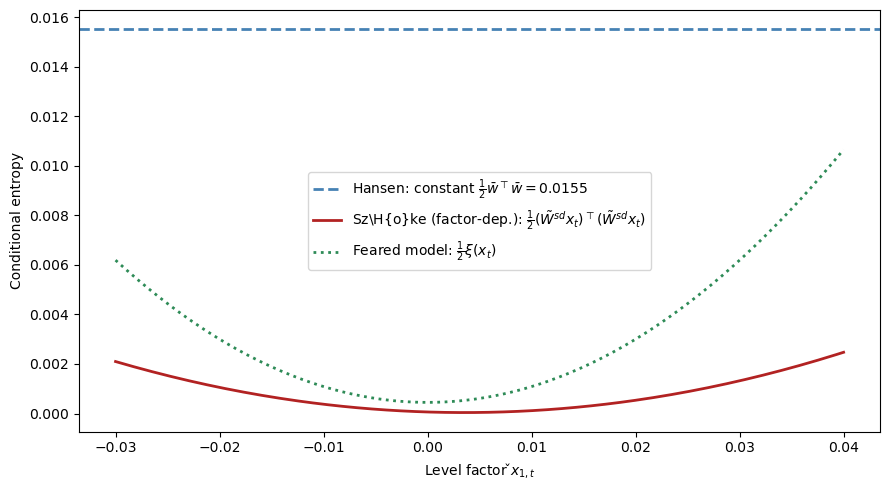

In [16]:
x_grid = np.linspace(-0.03, 0.04, 200)

entropy_tilted = np.array([
    tilted.state_dependent_entropy(
        augment_state(np.array([x, 0.005])))
    for x in x_grid])
ξ_vals = np.array([
    tilted.xi_function(
        augment_state(np.array([x, 0.005])))
    for x in x_grid])

# Calibrate Hansen's θ so constant entropy matches E[ξ(x_t)/2]
Σ_check = solve_discrete_lyapunov(A[1:, 1:], C[1:, :] @ C[1:, :].T)
E_xx = np.block([
    [np.ones((1, 1)), np.zeros((1, 2))],
    [np.zeros((2, 1)), Σ_check]
])
avg_ξ_half = 0.5 * np.trace(Ξ @ E_xx)
w_unit = hansen_worst_case(A, C, D, G, β, 1.0)
θ_hansen = norm(w_unit) / np.sqrt(2 * avg_ξ_half)
w_hansen = w_unit / θ_hansen
hansen_ent = 0.5 * w_hansen @ w_hansen

fig, ax = plt.subplots(figsize=(9, 5))
hansen_lab = (rf"Hansen: constant "
             rf"$\frac{{1}}{{2}}\bar{{w}}^\top"
             rf"\bar{{w}} = {hansen_ent:.4f}$")
ax.axhline(hansen_ent, color='steelblue',
           lw=2, ls='--', label=hansen_lab)
szoke_lab = (r"Sz\H{o}ke (factor-dep.): "
             r"$\frac{1}{2}(\tilde{W}^{sd}x_t)"
             r"^\top(\tilde{W}^{sd}x_t)$")
ax.plot(x_grid, entropy_tilted, 'firebrick',
        lw=2, label=szoke_lab)
ax.plot(x_grid, 0.5 * ξ_vals, 'seagreen', lw=2, ls=':',
        label=r"Feared model: $\frac{1}{2}\xi(x_t)$")
ax.set_xlabel(r"Level factor $\check{x}_{1,t}$")
ax.set_ylabel("Conditional entropy")
ax.legend()
plt.tight_layout()
plt.show()

The key innovation of the tilted entropy ball is visible: the factor-dependent component $\tilde{W}^{sd} x_t$ of the worst-case distortion grows with $|\check{x}_t|$, producing *countercyclical uncertainty prices*.

By contrast, Hansen's constant distortion $\bar{w}$ has entropy $\frac{1}{2}\bar{w}^\top\bar{w}$ that does not vary with the state (shown as a horizontal line).

The Szőke parabola lies inside the feared model's entropy budget $\frac{1}{2}\xi(x_t)$ along this slice, consistent with the tilted entropy constraint {eq}`eq_tilted_constraint`.

### Three probability twisters

To summarize, three distinct probability twisters play roles in this analysis:

| Symbol         | Source                        | Describes                         |
|:---------------|:------------------------------|:----------------------------------|
| $w_t^*$        | Piazzesi, Salomão, Schneider  | Mistaken agent's beliefs          |
| $\bar{w}_t$    | Szőke's feared parametric model | Especial LRR parametric worry   |
| $\tilde{W} x_t$  | Szőke's worst-case model      | State-dependent component of worst-case distortion |

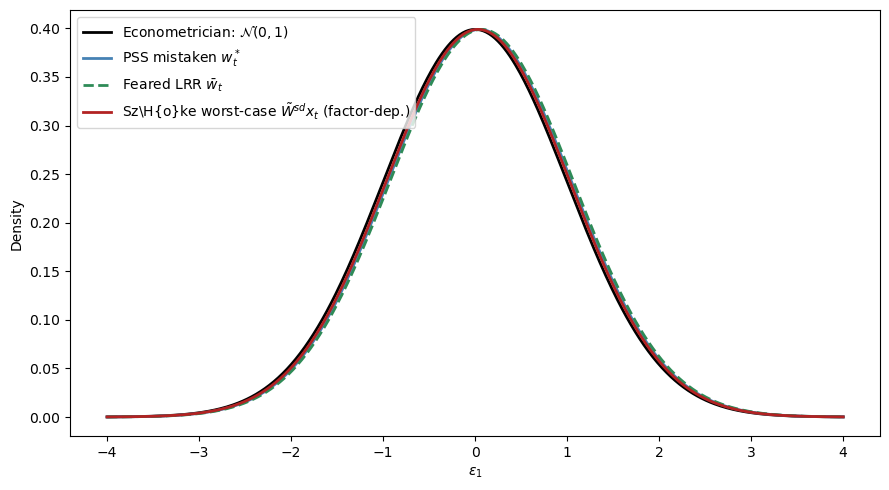

In [17]:
x_state = augment_state(np.array([0.02, 0.008]))
w_pss    = W_star @ x_state
w_feared = W_bar @ x_state
w_szoke  = tilted.state_dependent_distortion(x_state)

ε_grid = np.linspace(-4, 4, 500)
ϕ_base = normal_dist.pdf(ε_grid, 0, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ε_grid, ϕ_base, 'black', lw=2,
        label='Econometrician: $\\mathcal{N}(0,1)$')

for w_val, label, color, ls in [
    (w_pss[0], r"PSS mistaken $w^*_t$", 'steelblue', '-'),
    (w_feared[0], r"Feared LRR $\bar{w}_t$", 'seagreen', '--'),
    (w_szoke[0],
     r"Sz\H{o}ke worst-case $\tilde{W}^{sd}x_t$"
     r" (factor-dep.)", 'firebrick', '-'),
]:
    ax.plot(ε_grid, normal_dist.pdf(ε_grid, -w_val, 1),
            color=color, lw=2, ls=ls, label=label)

ax.set_xlabel(r"$\varepsilon_1$")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

Each twister shifts the econometrician's $\mathcal{N}(0,1)$ density by the displayed component, where the direction and magnitude depend on the current state $x_t$.

For the state shown here, all three displayed components are negative in their first element, so the twisted densities are shifted slightly to the right.

The shifts are small relative to the unit variance because the stochastic state $\check{x}_t = (0.02, 0.008)$ is close to the unconditional mean.

## Empirical challenges and model performances

Before comparing models, it helps to see the empirical regularities that any successful theory must explain.

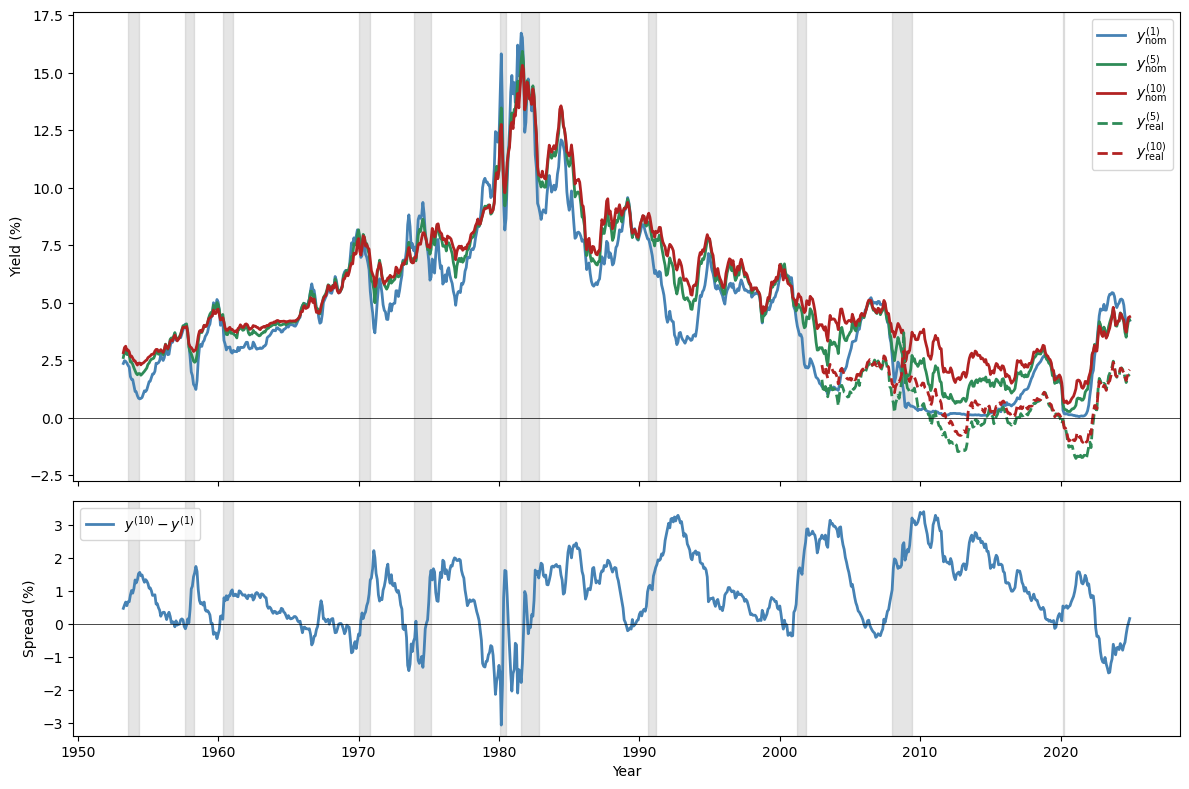

In [18]:
data = pd.read_csv(
    'https://raw.githubusercontent.com/QuantEcon/lecture-python.myst/refs/heads/'
    'main/lectures/_static/lecture_specific/risk_aversion_or_mistaken_beliefs/fred_data.csv',
    parse_dates=['DATE'], index_col='DATE'
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# Recession shading helper
def shade_recessions(ax, rec):
    ax.fill_between(rec.index, 0, 1,
                    where=rec.values.flatten() == 1,
                    transform=ax.get_xaxis_transform(),
                    color='grey', alpha=0.2)

rec = data['USREC'].dropna()

ax = axes[0]
shade_recessions(ax, rec)

ax.plot(data['GS1'], 'steelblue', lw=2,
        label=r'$y_{\mathrm{nom}}^{(1)}$')
ax.plot(data['GS5'], 'seagreen', lw=2,
        label=r'$y_{\mathrm{nom}}^{(5)}$')
ax.plot(data['GS10'], 'firebrick', lw=2,
        label=r'$y_{\mathrm{nom}}^{(10)}$')
ax.plot(data['DFII5'], 'seagreen', lw=2, ls='--',
        label=r'$y_{\mathrm{real}}^{(5)}$')
ax.plot(data['DFII10'], 'firebrick', lw=2, ls='--',
        label=r'$y_{\mathrm{real}}^{(10)}$')

ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Yield (%)')
ax.legend(loc='upper right')

ax2 = axes[1]
shade_recessions(ax2, rec)

spread_10_1 = data['GS10'] - data['GS1']
ax2.plot(spread_10_1, 'steelblue', lw=2,
         label=r'$y^{(10)} - y^{(1)}$')
ax2.axhline(0, color='black', lw=0.5)
ax2.set_ylabel('Spread (%)')
ax2.set_xlabel('Year')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

Several recognised patterns characterise the U.S. term structure:

- The nominal yield curve usually slopes *upward*.
- The long-minus-short yield spread *narrows before* U.S. recessions and
  *widens after* them.
- Consequently, the slope of the yield curve helps *predict* recessions and economic activity.
- Long and short yields are *almost equally volatile* (the Shiller "volatility puzzle").
- To solve the Shiller puzzle, risk prices (or something observationally equivalent)
  must *depend on volatile state variables*.

The following table summarises how various models perform:

| Model                          | Average slope | Slopes near recessions | Volatile long yield |
|:-------------------------------|:--------------|:-----------------------|:--------------------|
| {cite:t}`Lucas1978`            | no            | no                     | no                  |
| Epstein-Zin with LRR           | maybe         | yes                    | no                  |
| {cite:t}`piazzesi2015trend`    | built-in      | built-in               | yes                 |
| {cite:t}`szoke2022estimating`  | *YES*       | yes                    | yes                 |

### Why Szőke's model succeeds

Szőke's framework delivers:

1. A theory of *state-dependent belief distortions* with factor-dependent component $\tilde{W}^{sd} x_t$.
2. A theory about the *question that professional forecasters answer*: they
   respond with their worst-case model because they hear "tell me forecasts that
   rationalise your (max-min) decisions."
3. A way to *measure* the size of belief distortions relative to the
   econometrician's model.

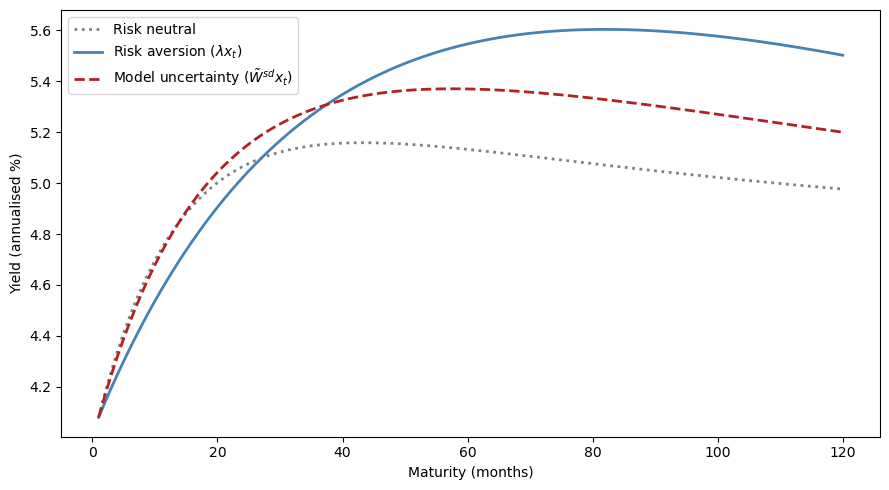

In [19]:
model_rn = LikelihoodRatioModel(
    A, C, D, G, r_bar, Λ=np.zeros_like(Λ))
model_uncert = LikelihoodRatioModel(
    A, C, D, G, r_bar, Λ=tilted.W_tilde_state)

x_test = augment_state(np.array([0.01, -0.03]))
n_max = 120
mats = np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mats, model_rn.yields(x_test, n_max) * 1200,
        'grey', lw=2, ls=':', label='Risk neutral')
ax.plot(mats, model.yields(x_test, n_max) * 1200,
        'steelblue', lw=2, label=r'Risk aversion ($\lambda x_t$)')
ax.plot(mats, model_uncert.yields(x_test, n_max) * 1200,
        'firebrick', lw=2, ls='--',
        label=r'Model uncertainty ($\tilde{W}^{sd} x_t$)')
ax.set_xlabel("Maturity (months)")
ax.set_ylabel("Yield (annualised %)")
ax.legend()
plt.tight_layout()
plt.show()

The risk-aversion-only and model-uncertainty-only yield curves both slope upward, generating a term premium. 

(Note that the model-uncertainty curve uses only the factor-dependent component $\tilde{W}^{sd} x_t$, not the full worst-case distortion.)

The two explanations represent *alternative channels* for the same observed term premium, reinforcing the identification challenge explored throughout this lecture.

## Cross-equation restrictions and estimation

A key appeal of the robust control approach is that it lets us deviate from rational expectations while still preserving a set of powerful **cross-equation restrictions** on decision makers' beliefs.

As {cite:t}`szoke2022estimating` puts it:

> An appealing feature of robust control theory is that it lets us deviate from
> rational expectations, but still preserves a set of powerful cross-equation
> restrictions on decision makers' beliefs. … Consequently, estimation can proceed
> essentially as with rational expectations econometrics. The main difference is
> that now restrictions through which we interpret the data emanate from the
> decision maker's best response to a worst-case model instead of to the
> econometrician's model.

### Szőke's empirical strategy

In the Szőke framework, the rational-expectations econometrician's risk price vector $\lambda_t$ is decomposed as $\lambda_t = \tilde{w}_t + \tilde{\lambda}_t$, paralleling the PSS decomposition $\lambda = \lambda^* + W^*$.

The combined likelihood ratio retains the same log-normal form as before, but now the total distortion vector $\lambda_t$ has an explicit decomposition into belief distortion and risk price components:

$$
m_{t+1}^\lambda = \exp \left(-\lambda_t^\top\varepsilon_{t+1} - \frac{1}{2}\lambda_t^\top\lambda_t\right), \qquad \lambda_t = \tilde{w}_t + \tilde\lambda_t
$$

Here $\tilde{w}_t = \tilde{W} x_t$ is the worst-case belief distortion, whose factor-dependent component is carried by the non-first columns of $\tilde{W}$, and $\tilde\lambda_t = \tilde\lambda x_t$ is the residual risk price.

In stage I (estimation):

1. Use $\{x_t, c_t\}_{t=0}^T$ to estimate the econometrician's $A$, $C$, $D$, $G$.
2. View $\Xi$ as a matrix of additional free parameters and estimate them
   simultaneously with risk prices $\tilde\lambda x_t$ from data
   $\{p_t(n+1)\}_{n=1}^N$, $t = 0, \ldots, T$, by imposing cross-equation
   restrictions:

$$
p_t(n+1) = \exp(-r_t) E_t \left[m_{t+1}^\lambda  p_{t+1}(n)\right]
$$

In stage II (assessment):

1. Assess improvements in predicted behaviour of the term structure.
2. Use estimated worst-case dynamics to form distorted forecasts
   $\tilde{E}_t[x_{t+1}] = (A - C\tilde{W})x_t$ and compare them to those of
   professional forecasters.
3. Compute the discounted KL divergence $\frac{1}{2}E^w[\sum \beta^t w_t^\top w_t]$ of
   each twisted model relative to the econometrician's model and compare them
   (the code below zeros the first column of $W$ and keeps only the factor-dependent part).

In [20]:
def discounted_kl(W, A_w, C, x0, β, T_horizon=500):
    """Factor-dependent KL: (1/2) E^w [Σ β^t (W x_t)'(W x_t)]."""
    n_sims = 10_000
    k = C.shape[1]
    rng = np.random.default_rng(2024)
    X = np.tile(x0, (n_sims, 1))
    total = np.zeros(n_sims)
    for t in range(T_horizon):
        w_t = X @ W.T
        total += β**t * 0.5 * np.sum(w_t**2, axis=1)
        X = X @ A_w.T + rng.standard_normal((n_sims, k)) @ C.T
    return np.mean(total)

x0_test = augment_state(np.array([0.01, 0.005]))
kl_szoke = discounted_kl(
    tilted.W_tilde_state,
    tilted.A_tilde_state, C, x0_test, β)
kl_feared = discounted_kl(W_bar, A_bar, C, x0_test, β)

print(f"Szőke factor-dep. KL: {kl_szoke:.4f}")
print(f"Feared LRR KL:       {kl_feared:.4f}")
status = ('closer to' if kl_szoke < kl_feared
          else 'farther from')
print(f"\nWorst-case model is {status} "
      f"the econometrician's model.")

Szőke factor-dep. KL: 1.0730
Feared LRR KL:       10.7140

Worst-case model is closer to the econometrician's model.


Using only the factor-dependent component $\tilde{W}^{sd} x_t$, the Szőke worst-case model has lower discounted KL divergence from the econometrician's model than the feared long-run risk model, meaning it is statistically harder to distinguish from the baseline.

Yet it still generates the state-dependent uncertainty prices needed to match term-structure dynamics.

## Who cares?

Joint probability distributions of interest rates and macroeconomic shocks are important throughout macroeconomics:

- *Costs of aggregate fluctuations.* Welfare assessments of business cycles
  depend sensitively on how risks are priced.
- *Consumption Euler equations.* The "New Keynesian IS curve" is a log-linearised
  consumption Euler equation whose risk adjustments are controlled by the stochastic
  discount factor.
- *Optimal taxation and government debt management.* Government bond prices embed
  risk prices whose state dependence matters for optimal fiscal policy.
- *Central bank expectations management.* Forward guidance works by shifting the
  term structure, an exercise whose effects depend on the same likelihood ratios
  studied here.
- *Long-run risk and secular stagnation.* The Bansal-Yaron long-run risk
  hypothesis is difficult to detect statistically, yet an agent who fears it in
  the sense formalised above may behave very differently than one who does not.

Understanding whether observed asset prices reflect risk aversion, mistaken beliefs, or fears of model misspecification, and quantifying each component, is interesting for both positive and normative macroeconomics.


## Related lectures

This lecture connects to several others in the series:

- {ref}`Doubts or Variability? <doubts_or_variability>` studies how a preference for robustness generates worst-case likelihood ratios that look like stochastic discount factor shocks, complementing the analysis here with Hansen-Jagannathan bounds and detection-error probabilities.
- {ref}`Asset Pricing: Finite State Models <mass>` introduces stochastic discount factors and risk-neutral pricing in a finite-state Markov setting, the discrete-state counterpart of the continuous Gaussian framework used here.
- {ref}`Heterogeneous Beliefs and Bubbles <harrison_kreps>` examines how heterogeneous and possibly mistaken beliefs generate speculative asset price bubbles, providing another perspective on how beliefs affect asset prices.
- {ref}`Likelihood Ratio Processes <likelihood_ratio_process>` develops the mathematical properties of likelihood ratios, the central device organising this lecture, including their martingale structure and statistical applications.
- {ref}`Divergence Measures <divergence_measures>` covers Kullback-Leibler divergence and relative entropy in detail, providing the information-theoretic foundations for the entropy constraints used in the robust control sections.
- {ref}`Affine Models of Asset Prices <affine_risk_prices>` extends the linear Gaussian state-space framework to affine and exponential-quadratic stochastic discount factors, developing risk-neutral pricing formulas closely related to those derived here.